In [50]:
# Data handling libraries
import pandas as pd
import numpy as np

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
# Model saving library
import joblib

In [68]:
df=pd.read_csv("medical_disease_mapped.csv")

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sugar             1659 non-null   float64
 1   HemoglobinLevels  1659 non-null   float64
 2   CholesterolTotal  1659 non-null   float64
 3   Name              1659 non-null   object 
 4   Date_of_Birth     1659 non-null   object 
 5   disease_name      1659 non-null   object 
dtypes: float64(3), object(3)
memory usage: 77.9+ KB


In [7]:
df.isnull().sum()

,0
Sugar,0
HemoglobinLevels,0
CholesterolTotal,0
Name,0
Date_of_Birth,0
diagnosis_multiclass,0


In [8]:
df.describe()

,Sugar,HemoglobinLevels,CholesterolTotal
count,1659.000000,1659.000000,1659.000000
mean,6.983682,13.927304,224.251158
std,1.734714,2.338372,43.666586
min,4.000405,10.004223,150.015707
25%,5.494988,11.839478,186.440971
50%,6.988001,13.909388,223.202106
75%,8.523562,16.012084,262.681917
max,9.998393,17.999656,299.950846


In [9]:
df.duplicated().sum()


np.int64(0)

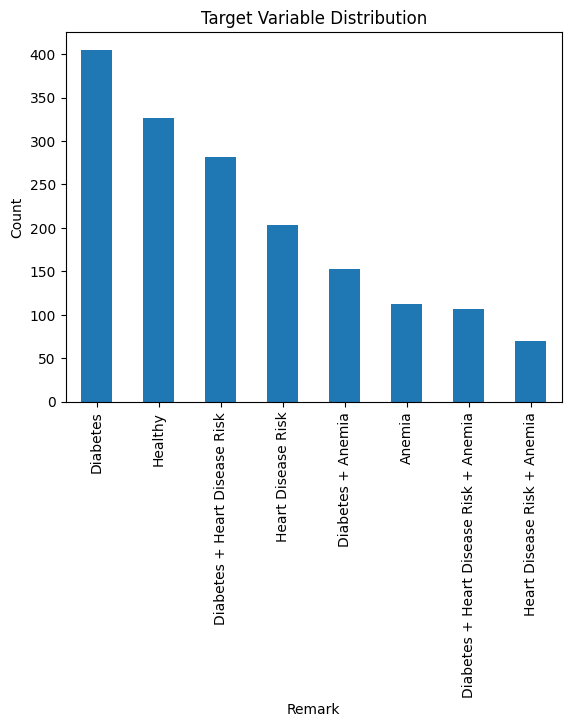

In [70]:
import matplotlib.pyplot as plt

df["disease_name"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Remark")
plt.ylabel("Count")

plt.show()

In [72]:
# Check percentage distribution
print(df["disease_name"].value_counts(normalize=True) * 100)

disease_name
Diabetes                                  24.412297
Healthy                                   19.710669
Diabetes + Heart Disease Risk             16.937914
Heart Disease Risk                        12.236287
Diabetes + Anemia                          9.222423
Anemia                                     6.811332
Diabetes + Heart Disease Risk + Anemia     6.449668
Heart Disease Risk + Anemia                4.219409
Name: proportion, dtype: float64


In [73]:
X = df[["Sugar", "HemoglobinLevels", "CholesterolTotal"]]

y = df["disease_name"]

In [74]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded

)

In [76]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



In [77]:
print(y_train_smote.value_counts())

disease_name
Diabetes                                  324
Diabetes + Anemia                         324
Healthy                                   324
Diabetes + Heart Disease Risk + Anemia    324
Heart Disease Risk                        324
Diabetes + Heart Disease Risk             324
Anemia                                    324
Heart Disease Risk + Anemia               324
Name: count, dtype: int64


In [78]:
# Import algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [79]:
log_model = LogisticRegression(max_iter=1000)

In [80]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [81]:
log_model.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [82]:
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [83]:
log_pred = log_model.predict(X_test)

In [84]:
rf_pred = rf_model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score

# Logistic Regression Accuracy
log_acc = accuracy_score(y_test, log_pred)

# Random Forest Accuracy
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", log_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.963855421686747
Random Forest Accuracy: 1.0


In [86]:
from sklearn.metrics import classification_report

print("Logistic Regression Report")
print(classification_report(y_test, log_pred))

Logistic Regression Report
                                        precision    recall  f1-score   support

                                Anemia       0.96      0.96      0.96        23
                              Diabetes       0.98      0.98      0.98        81
                     Diabetes + Anemia       0.91      0.97      0.94        31
         Diabetes + Heart Disease Risk       0.98      1.00      0.99        56
Diabetes + Heart Disease Risk + Anemia       0.95      0.90      0.93        21
                               Healthy       0.98      0.94      0.96        65
                    Heart Disease Risk       0.95      0.98      0.96        41
           Heart Disease Risk + Anemia       0.93      0.93      0.93        14

                              accuracy                           0.96       332
                             macro avg       0.95      0.96      0.96       332
                          weighted avg       0.96      0.96      0.96       332



In [87]:
print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Random Forest Report
                                        precision    recall  f1-score   support

                                Anemia       1.00      1.00      1.00        23
                              Diabetes       1.00      1.00      1.00        81
                     Diabetes + Anemia       1.00      1.00      1.00        31
         Diabetes + Heart Disease Risk       1.00      1.00      1.00        56
Diabetes + Heart Disease Risk + Anemia       1.00      1.00      1.00        21
                               Healthy       1.00      1.00      1.00        65
                    Heart Disease Risk       1.00      1.00      1.00        41
           Heart Disease Risk + Anemia       1.00      1.00      1.00        14

                              accuracy                           1.00       332
                             macro avg       1.00      1.00      1.00       332
                          weighted avg       1.00      1.00      1.00       332



In [89]:
import joblib
# Save the trained model
joblib.dump(rf_model, "health_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [93]:
# Load saved model
loaded_model = joblib.load("health_model.pkl")

print("Model loaded successfully.")
# Sample prediction

sample_data = [[8, 15, 600]]

prediction = loaded_model.predict(sample_data)

print("Prediction:", prediction)

Model loaded successfully.
Prediction: ['Diabetes + Heart Disease Risk']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [51]:
# Check feature importance

importance = rf_model.feature_importances_

feature_names = X.columns

for feature, score in zip(feature_names, importance):
    print(feature, ":", score)

Blood_Sugar : 0.31644486203521793
Hemoglobin : 0.40033908627871334
Cholesterol : 0.28321605168606867
